# Model Evaluation — Africa Growth Explorer

**This notebook does not select or train anything.** Selection, gating and the
single sealed-test evaluation all happen in `scripts/finalize_model.py`
(expanding-window CV inside the training period, baseline gate on validation,
test touched exactly once). Here we only *load the deployed artifacts* and
explain them — this is the C2 remediation: the notebook and the deployment
cannot disagree because the notebook reads the deployment.

If the artifacts change, re-run `python scripts/finalize_model.py` first, then
re-execute this notebook; a consistency guard cell below fails loudly if the
two ever drift apart.

Sections: §1 setup → §2 validation & gate → §3 sealed test → §4 fit &
residuals → §5 interpretation (importance + Ridge direction) → §6
uncertainty (bootstrap CIs, paired significance) → §7 error analysis →
§8 COVID placement & refit policy.

## 1. Setup

In [1]:
# Portable root resolution: env var > git root > parent of notebooks/
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", "")) if os.environ.get("PROJECT_ROOT") else None
if PROJECT_ROOT is None:
    here = Path.cwd()
    PROJECT_ROOT = next(
        (p for p in [here, *here.parents] if (p / "pyproject.toml").exists()),
        here.parent,
    )
assert (PROJECT_ROOT / "config" / "indicators.yaml").exists(), \
    f"Could not resolve project root (got {PROJECT_ROOT})"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

import json
import logging

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from src.config import load_config
from src.evaluate import compute_bootstrap_ci, compute_metrics_by_group, compute_worst_errors
from src.visualization import (
    set_project_style, get_project_palette,
    plot_actual_vs_predicted, plot_residuals, plot_feature_importance,
)

logging.basicConfig(level=logging.WARNING)
set_project_style()
PALETTE = get_project_palette()
config = load_config(PROJECT_ROOT / "config" / "indicators.yaml")
name_of = {f.code: f.name for f in config.features}

Project root: /home/user/africa-growth-ml


## 2. The deployed artifact and how it was chosen (validation-side view)

In [2]:
metadata = json.loads((PROJECT_ROOT / "models" / "model_metadata.json").read_text())
pipeline = joblib.load(PROJECT_ROOT / "models" / "growth_model.joblib")

winner_name = metadata["model_type"]
print(f"Deployed model (selected on validation in scripts/finalize_model.py): {winner_name}")
print(f"Selection gate passed: {metadata['gate']['passed']}")
print(f"Refit strategy (pre-registered): {metadata['refit_strategy']}")
print(f"Features: {metadata['n_features']} | random_state: {metadata['random_state']} | "
      f"git commit: {str(metadata['git_commit'])[:8]}")

Deployed model (selected on validation in scripts/finalize_model.py): HistGradientBoostingRegressor
Selection gate passed: True
Refit strategy (pre-registered): train_only
Features: 14 | random_state: 42 | git commit: cc78b7fb


In [3]:
mm = metadata["metrics"]
val_rows = [
    {"model": "Global-mean baseline", "val_MAE": mm["val_baselines"]["global_mean"]["mae"]},
    {"model": "Persistence baseline", "val_MAE": mm["val_baselines"]["persistence"]["mae"]},
    {"model": "Ridge (CV-best alpha)", "val_MAE": mm["ridge_val"]["mae"]},
    {"model": "HGB (CV-best config)", "val_MAE": mm["hgb_val"]["mae"]},
]
val_table = pd.DataFrame(val_rows).sort_values("val_MAE").reset_index(drop=True)
gate = metadata["gate"]
print("Validation MAE — selection evidence (never test):")
val_table

Validation MAE — selection evidence (never test):


,model,val_MAE
0,HGB (CV-best config),3.886914
1,Ridge (CV-best alpha),4.004345
2,Global-mean baseline,4.038251
3,Persistence baseline,5.020743


In [4]:
print(f"Baseline gate (runs BEFORE any artifact is written): "
      f"{'PASSED' if gate['passed'] else 'FAILED'}")
for b, r in gate["per_baseline"].items():
    print(f"  vs {b:<12} candidate {r['candidate_value']:.4f} vs baseline "
          f"{r['baseline_value']:.4f}  (margin {r['margin']:+.4f}, "
          f"{r['relative_margin_pct']:+.2f}%)")

Baseline gate (runs BEFORE any artifact is written): PASSED
  vs global_mean  candidate 3.8869 vs baseline 4.0383  (margin +0.1513, +3.75%)
  vs persistence  candidate 3.8869 vs baseline 5.0207  (margin +1.1338, +22.58%)


### Expanding-window CV (spec §9) — executed inside the training period only
Folds: train 2000–2010 → val 2011–12, train 2000–2012 → val 2013–14,
train 2000–2014 → val 2015–16. The real held-out validation split (2018–2020
features) and the test split are **not** part of tuning.

In [5]:
ridge_cv = pd.read_csv(PROJECT_ROOT / "models" / "cv_results_ridge.csv")
hgb_cv = pd.read_csv(PROJECT_ROOT / "models" / "cv_results_hgb.csv")
print("Ridge alpha grid (mean fold MAE, ascending):")
display(ridge_cv)
print("HGB grid (mean fold MAE, ascending):")
display(hgb_cv)
best = hgb_cv.iloc[0]
print(f"Picked HGB config: depth={int(best['max_depth'])}, lr={best['learning_rate']}, "
      f"max_iter={int(best['max_iter'])} (mean CV MAE {best['mean_mae']:.4f}, "
      f"+/- {best['std_mae']:.4f})")

Ridge alpha grid (mean fold MAE, ascending):


,alpha,mean_mae,std_mae,n_folds
0,3000.0,3.303103,0.765860,3
1,1000.0,3.353920,0.787174,3
2,300.0,3.461750,0.831195,3
3,100.0,3.544528,0.843204,3
4,10.0,3.626366,0.829912,3
5,1.0,3.645854,0.827976,3


HGB grid (mean fold MAE, ascending):


,max_depth,learning_rate,max_iter,mean_mae,std_mae,n_folds
0,2,0.03,200,3.212910,0.749385,3
1,2,0.03,100,3.213601,0.748814,3
2,3,0.01,100,3.215395,0.757848,3
3,2,0.01,100,3.218259,0.748135,3
4,2,0.05,100,3.219939,0.746553,3
5,3,0.01,200,3.225037,0.746716,3
6,2,0.01,200,3.225039,0.749031,3
7,2,0.05,200,3.225100,0.753821,3
8,3,0.03,100,3.234790,0.738301,3
9,3,0.03,200,3.234790,0.738301,3


Picked HGB config: depth=2, lr=0.03, max_iter=200 (mean CV MAE 3.2129, +/- 0.7494)


### Interpretation
CV ranks a deliberately shrunken HGB (depth 2, small lr, L2=1.0, explicit early stopping) best inside the training period — the shipped model is now the same one these folds selected, and the validation-baseline gate is what protects the deployment (C1).

## 3. Sealed test — numbers reported once, from the frozen artifact
These come from `models/test_predictions.parquet` written by finalize Step H.
Nothing is refit or reselected here.

In [6]:
test_preds = pd.read_parquet(PROJECT_ROOT / "models" / "test_predictions.parquet")
fy = metadata["split_target_years"]
print(f"Test rows: {len(test_preds)} | feature years {fy['test'][0]-1}-{fy['test'][1]-1} "
      f"-> target years {fy['test'][0]}-{fy['test'][1]}")

t_rows = [
    {"model": "Global-mean baseline", **{k: mm["global_mean_baseline"][k] for k in
        ("mae", "rmse", "r2", "directional_accuracy", "directional_majority_rate",
         "directional_skill")}},
    {"model": "Persistence baseline", **{k: mm["persistence_baseline"][k] for k in
        ("mae", "rmse", "r2", "directional_accuracy", "directional_majority_rate",
         "directional_skill")}},
    {"model": "Country historical-mean baseline", **{k: mm["country_historical_mean_baseline"][k]
        for k in ("mae", "rmse", "r2", "directional_accuracy", "directional_majority_rate",
                  "directional_skill")}},
    {"model": f"Deployed {winner_name}", **{k: mm["winner_test"][k] for k in
        ("mae", "rmse", "r2", "directional_accuracy", "directional_majority_rate",
         "directional_skill")}},
]
test_table = pd.DataFrame(t_rows)
print("Test-set comparison (H4: directional accuracy is only meaningful against the "
      "majority-class rate):")
test_table

Test rows: 150 | feature years 2021-2023 -> target years 2022-2024
Test-set comparison (H4: directional accuracy is only meaningful against the majority-class rate):


,model,mae,rmse,r2,directional_accuracy,directional_majority_rate,directional_skill
0,Global-mean baseline,1.895766,2.837858,-0.000522,0.806667,0.806667,0.000000
1,Persistence baseline,2.228654,4.520915,-1.539206,0.773333,0.806667,-0.033333
2,Country historical-mean baseline,1.942401,2.881619,-0.031617,0.780000,0.806667,-0.026667
3,Deployed HistGradientBoostingRegressor,1.821733,2.794184,0.030037,0.806667,0.806667,0.000000


### Interpretation — the honest headline
The deployed model attains a test MAE marginally below the global-mean baseline,
but the paired bootstrap CI (§6) spans zero: **the model is statistically
indistinguishable from predicting the unconditional mean.** Directional accuracy
is reported next to the majority-class rate because any always-positive
constant scores 80.7% by construction (H4). Parity with the mean at annual
frequency is the substantive finding of this capstone, not a defect to hide.

## 4. Actual vs predicted (deployed model, test set)

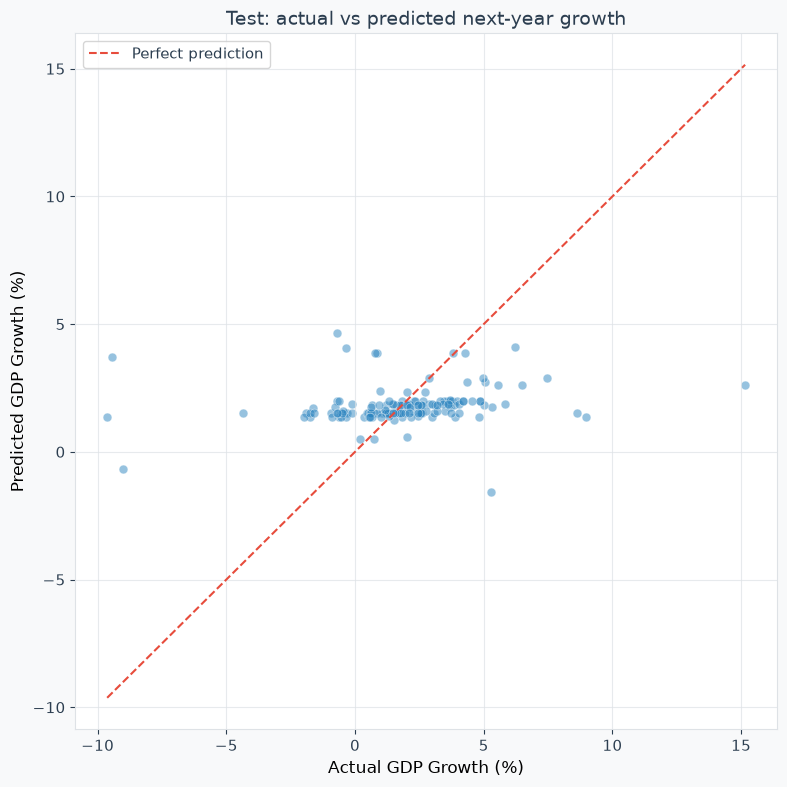

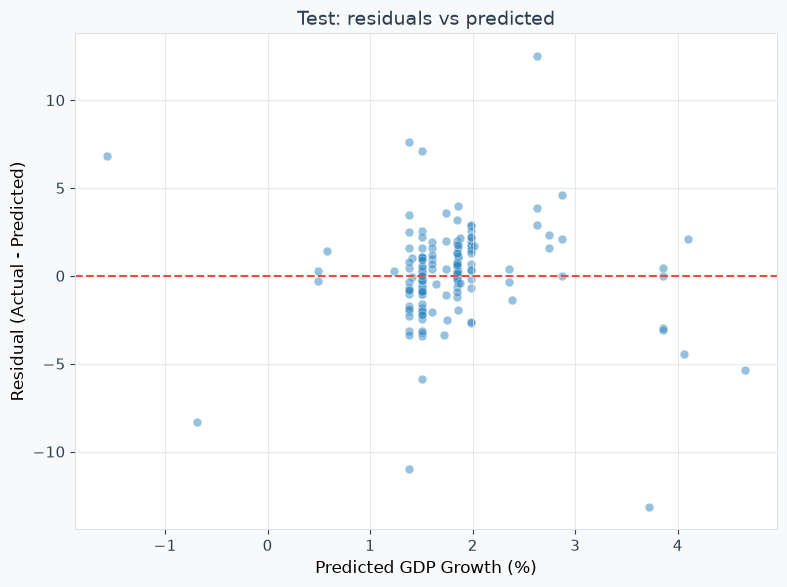

Mean residual (actual - predicted): +0.0804 pp — a model bias of this size was the C6 mechanism when refitting on train+val; the pre-registered 'train_only' policy keeps it small.


In [7]:
fig = plot_actual_vs_predicted(test_preds["actual"].to_numpy(),
                               test_preds["predicted"].to_numpy(),
                               title="Test: actual vs predicted next-year growth")
plt.show()
fig = plot_residuals(test_preds["actual"].to_numpy(), test_preds["predicted"].to_numpy(),
                     title="Test: residuals vs predicted")
plt.show()
mean_resid = float((test_preds["actual"] - test_preds["predicted"]).mean())
print(f"Mean residual (actual - predicted): {mean_resid:+.4f} pp — a model bias of this "
      f"size was the C6 mechanism when refitting on train+val; the pre-registered "
      f"'{metadata['refit_strategy']}' policy keeps it small.")

## 5. Interpretation — permutation importance (magnitude) + Ridge coefficients (direction)

H1 remediation: importance is computed on **validation** with bootstrap-style
permutation CIs; features whose CI straddles zero are indistinguishable from
noise and are *not* given any directional reading. Direction comes exclusively
from the standardized Ridge coefficients (spec §13), mapped through
`get_transformed_feature_names` (H2: a ColumnTransformer permutes columns, so
`zip(features, coef_)` would mislabel them).

In [8]:
imp = pd.read_parquet(PROJECT_ROOT / "models" / "feature_importance.parquet")
imp = imp.assign(display=imp["feature"].map(lambda c: name_of.get(c, c)))
sig = imp[imp["is_significant"]]
noisy = imp[~imp["is_significant"]]
print(f"{len(sig)}/{len(imp)} features distinguishable from noise at 95% on validation")
imp[["display", "importance_mean", "importance_std", "ci_lower", "ci_upper", "is_significant"]]

2/14 features distinguishable from noise at 95% on validation


,display,importance_mean,importance_std,ci_lower,ci_upper,is_significant
0,GDP per capita (current US$),0.046327,0.016085,0.018149,0.084551,True
1,Population growth (annual %),0.017376,0.011493,0.000211,0.037385,True
2,"Foreign direct investment, net inflows (% of GDP)",0.003267,0.004472,-0.000604,0.013518,False
3,NY.GDP.PCAP.KD.ZG,0.002505,0.011282,-0.014779,0.023324,False
4,Urban population (% of total population),0.001595,0.002007,-0.002492,0.004871,False
5,Domestic credit to private sector (% of GDP),0.000334,0.001249,-0.001665,0.003047,False
6,"Life expectancy at birth, total (years)",0.000147,0.001016,-0.001528,0.001871,False
7,Individuals using the Internet (% of population),0.000000,0.000000,0.000000,0.000000,False
8,"Inflation, consumer prices (annual %)",0.000000,0.000000,0.000000,0.000000,False
9,Access to electricity (% of population),0.000000,0.000000,0.000000,0.000000,False


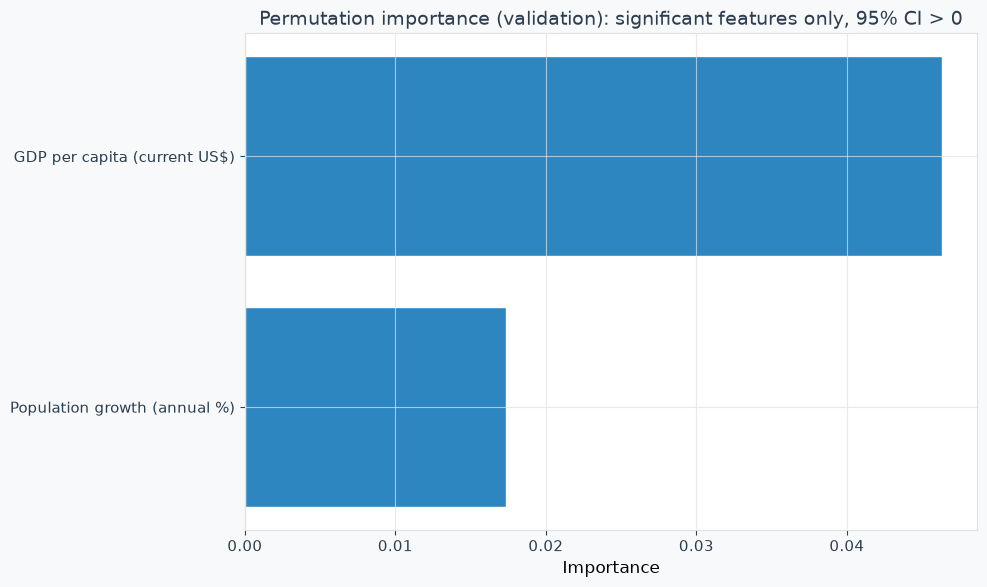

In [9]:
if not sig.empty:
    series = pd.Series(sig["importance_mean"].to_numpy(), index=sig["display"].to_numpy())
    fig = plot_feature_importance(series, title="Permutation importance (validation): "
                                               "significant features only, 95% CI > 0")
    plt.show()
else:
    print("No feature's permutation importance CI excludes zero: the model's learned "
          "signal is noise. (H1: this must be stated, not dressed up.)")

In [10]:
rc = pd.read_parquet(PROJECT_ROOT / "models" / "ridge_coefficients.parquet")
rc = rc.assign(display=rc["feature"].map(lambda s: s.replace("NY.GDP.PCAP.CD", "GDP per capita (log1p)")))
rc = rc.assign(display=rc["display"].map(lambda s: name_of.get(s, s)))
print("Ridge standardized coefficients (CV-best alpha, fit on train; direction view):")
rc[["display", "coefficient"]]

Ridge standardized coefficients (CV-best alpha, fit on train; direction view):


,display,coefficient
0,"Foreign direct investment, net inflows (% of GDP)",0.142693
1,Urban population (% of total population),-0.074669
2,GDP per capita (log1p)_log1p,-0.067078
3,Population growth (annual %),-0.045872
4,Gross capital formation (% of GDP),0.043899
5,Access to electricity (% of population),0.037736
6,General government final consumption expenditu...,0.034281
7,"Inflation, consumer prices (annual %)",-0.028147
8,"Life expectancy at birth, total (years)",-0.027434
9,"Unemployment, total (% of total labor force)",0.026310


### Interpretation
Permutation importances that cluster around zero with CIs crossing zero (the 'noise' table above) are exactly what a no-signal regime looks like — earlier versions of this project labelled them 'Positive/Negative drivers', a category error (H1). Ridge coefficients provide *associational direction at best*, on a model with no significant skill; they are reported for completeness, and the causal boundary in the spec (§2) applies regardless.

## 6. Uncertainty — bootstrap CIs and the paired significance test

In [11]:
actual = test_preds["actual"].to_numpy()
pred = test_preds["predicted"].to_numpy()
mae_lo, mae_hi = compute_bootstrap_ci(actual, pred,
    lambda a, p: float(np.mean(np.abs(a - p))), n_bootstrap=2000)
rmse_lo, rmse_hi = compute_bootstrap_ci(actual, pred,
    lambda a, p: float(np.sqrt(np.mean((a - p) ** 2))), n_bootstrap=2000)
print(f"Deployed model bootstrap CIs (2,000 resamples): "
      f"MAE [{mae_lo:.3f}, {mae_hi:.3f}] | RMSE [{rmse_lo:.3f}, {rmse_hi:.3f}]")

s = metadata["significance"]
verdict = ("SIGNIFICANT at 95%" if s["significant_at_95"]
           else "NOT significant at 95% - CI includes zero: the model is not "
                "statistically distinguishable from the unconditional mean")
print(f"Paired MAE improvement vs global-mean baseline: "
      f"{s['paired_mae_improvement_vs_global_mean']:+.4f} pp "
      f"[{s['ci_lower']:+.4f}, {s['ci_upper']:+.4f}] -> {verdict}")

Deployed model bootstrap CIs (2,000 resamples): MAE [1.517, 2.179] | RMSE [2.165, 3.407]
Paired MAE improvement vs global-mean baseline: +0.0740 pp [-0.0422, +0.1868] -> NOT significant at 95% - CI includes zero: the model is not statistically distinguishable from the unconditional mean


## 7. Error analysis — worst cases and where errors concentrate

In [12]:
worst = compute_worst_errors(test_preds, top_n=10)[
    ["country_name", "year", "actual", "predicted", "abs_error"]]
print("Top 10 absolute errors (all values in pp of growth):")
worst

Top 10 absolute errors (all values in pp of growth):


,country_name,year,actual,predicted,abs_error
72,Libya,2021,-9.424902,3.721805,13.146707
33,Cabo Verde,2021,15.154508,2.627849,12.526659
64,Equatorial Guinea,2022,-9.629959,1.376366,11.006325
123,Seychelles,2021,-9.019861,-0.688369,8.331493
73,Libya,2022,8.965347,1.376366,7.588981
99,Niger,2021,8.631126,1.505861,7.125265
124,Seychelles,2022,5.272017,-1.565088,6.837104
14,Botswana,2023,-4.356882,1.505861,5.862743
100,Niger,2022,-0.691443,4.656743,5.348186
105,Rwanda,2021,7.445451,2.874683,4.570769


In [13]:
by_year = compute_metrics_by_group(test_preds, group_col="year")
print("Metrics by target year:")
by_year[["year", "mae", "rmse", "directional_accuracy", "directional_skill"]]

Metrics by target year:


,year,mae,rmse,directional_accuracy,directional_skill
0,2021,2.058439,3.445664,0.84,0.02
1,2022,1.851834,2.762975,0.78,-0.02
2,2023,1.554925,1.978828,0.80,0.00


In [14]:
by_country = compute_metrics_by_group(test_preds, group_col="country_name")
by_c = by_country.sort_values("mae")
print("Countries with smallest / largest test MAE:")
pd.concat([by_c.head(5), by_c.tail(5)])[
    ["country_name", "mae", "rmse", "directional_accuracy"]]

Countries with smallest / largest test MAE:


,country_name,mae,rmse,directional_accuracy
28,Madagascar,0.163250,0.188969,1.000000
19,Gabon,0.284688,0.285878,1.000000
30,Mali,0.396518,0.522843,1.000000
44,Tanzania,0.439177,0.525849,1.000000
26,Liberia,0.445488,0.532507,1.000000
16,Equatorial Guinea,5.028835,6.657754,0.333333
35,Niger,5.307975,5.515985,0.666667
40,Seychelles,5.530040,6.276424,0.666667
6,Cabo Verde,5.597755,7.568878,1.000000
27,Libya,7.909163,8.932700,0.666667


### Interpretation
The worst errors are real macro surprises — post-conflict rebounds, oil booms/busts, currency crashes — which no lagged annual WDI snapshot could anticipate. That, plus the parity result, is the argument that annual-frequency aggregates are the wrong resolution for growth *prediction* (they remain useful for *description*).

## 8. COVID placement, split definition and the refit decision (C6)

Splits are described in **feature** years everywhere (train 2000–2017, val
2018–2020, test 2021+); in **target** years they shift by one. The metadata
records both explicitly because the ambiguity hid a real mechanism: the 2020
COVID crash lands in the validation *target* window, so a train+val refit bakes
a depressed central tendency into a model evaluated on post-pandemic targets.

In [15]:
st = metadata["split_target_years"]
ss = metadata["split_sizes"]
rows = [
    {"split": "train", "feature_years": f"{st['train'][0]-1}-{st['train'][1]-1}",
     "target_years": f"{st['train'][0]}-{st['train'][1]}", "n": ss["train"]},
    {"split": "val", "feature_years": f"{st['val'][0]-1}-{st['val'][1]-1}",
     "target_years": f"{st['val'][0]}-{st['val'][1]}", "n": ss["val"]},
    {"split": "test", "feature_years": f"{st['test'][0]-1}-{st['test'][1]-1}",
     "target_years": f"{st['test'][0]}-{st['test'][1]}", "n": ss["test"]},
]
pd.DataFrame(rows)

,split,feature_years,target_years,n
0,train,2000-2017,2001-2018,905
1,val,2018-2020,2019-2021,150
2,test,2021-2023,2022-2024,150


In [16]:
sens = metadata["sensitivity"]["refit_train_val"]
primary = metadata["metrics"]["winner_test"]
print(f"Primary (pre-registered '{metadata['refit_strategy']}'): "
      f"test MAE {primary['mae']:.4f}, mean residual "
      f"{float((test_preds['actual']-test_preds['predicted']).mean()):+.4f} pp")
print(f"Sensitivity (train+val refit): test MAE {sens['test_metrics']['mae']:.4f}, "
      f"prediction-minus-actual bias {sens['mean_prediction'] - sens['mean_actual']:+.4f} pp")
print(sens["bias_note"])

Primary (pre-registered 'train_only'): test MAE 1.8217, mean residual +0.0804 pp
Sensitivity (train+val refit): test MAE 2.0341, prediction-minus-actual bias -0.8558 pp
train+val refit absorbs the 2020 COVID crash (validation target mean is far below test target mean), depressing central tendency on test - the C6 mechanism


The refit strategy was fixed **before** looking at test (pre-registered, rationale:
regime mismatch of the COVID crash), and the sensitivity numbers above merely
document the size of the effect — consistent with the C6 diagnosis, the
train+val variant is worse on test and more biased.

### Interpretation
Validation targets (2019–2021) include the −4.76pp COVID mean; test targets
(2022–2024) average ≈ +1.9pp. This distribution shift across the target
horizon — not model class choice — is why refit scope matters more than any
hyperparameter here.

## 9. Consistency guard (prevents C2 recurrence)

In [17]:
# Guard: notebook numbers must match the deployed artifact exactly.
nb_mae = float(np.mean(np.abs(test_preds["actual"] - test_preds["predicted"])))
meta_mae = float(metadata["metrics"]["winner_test"]["mae"])
assert abs(nb_mae - meta_mae) < 1e-6, f"Notebook {nb_mae} != metadata {meta_mae}"
print(f"Consistency OK: test MAE {nb_mae:.4f} matches model_metadata.json")

Consistency OK: test MAE 1.8217 matches model_metadata.json
